# Homework 3: Elasticity & CPI Data Analysis with Python
## Part 1: Elasticity Practice
### Question 1. Create the Demand Schedule DataFrame and Compute Elasticity


In [13]:
import pandas as pd
import numpy as np

# --- Question 1: Create the Demand Schedule DataFrame ---

# (a) Create the demand schedule
data = {
    'Price': [1, 2, 3, 4, 5, 6, 6.5, 7, 8, 9, 10],
    'Quantity': [100, 90, 80, 70, 60, 50, 45, 40, 30, 20, 10]
}
df = pd.DataFrame(data)
print("Demand Schedule:")
print(df.to_string(index=False))

# (c) Compute Price Elasticity of Demand using the midpoint method
#     Ed = (ΔQ / ΔP) × (avg P / avg Q)
df['Delta_Q'] = df['Quantity'].diff()
df['Delta_P'] = df['Price'].diff()
df['Avg_P'] = (df['Price'] + df['Price'].shift(1)) / 2
df['Avg_Q'] = (df['Quantity'] + df['Quantity'].shift(1)) / 2

df['Elasticity'] = (df['Delta_Q'] / df['Delta_P']) * (df['Avg_P'] / df['Avg_Q'])

print("\nDemand Schedule with Price Elasticity of Demand (Midpoint Method):")
print(df[['Price', 'Quantity', 'Elasticity']].to_string(index=False))

Demand Schedule:
 Price  Quantity
   1.0       100
   2.0        90
   3.0        80
   4.0        70
   5.0        60
   6.0        50
   6.5        45
   7.0        40
   8.0        30
   9.0        20
  10.0        10

Demand Schedule with Price Elasticity of Demand (Midpoint Method):
 Price  Quantity  Elasticity
   1.0       100         NaN
   2.0        90   -0.157895
   3.0        80   -0.294118
   4.0        70   -0.466667
   5.0        60   -0.692308
   6.0        50   -1.000000
   6.5        45   -1.315789
   7.0        40   -1.588235
   8.0        30   -2.142857
   9.0        20   -3.400000
  10.0        10   -6.333333


### Question 2: Plot the Demand Curve & Price Elasticity

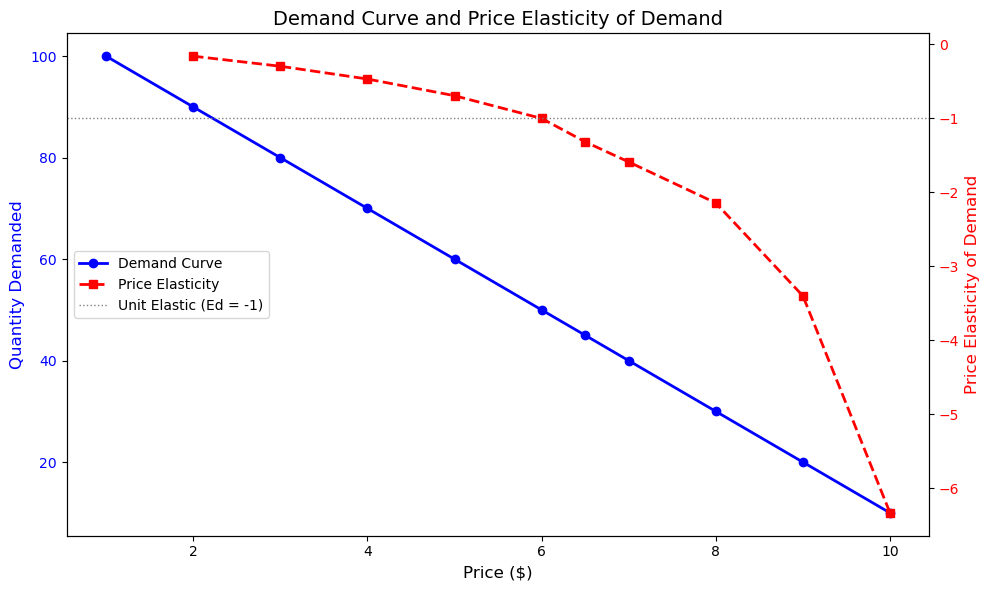

In [14]:
import matplotlib.pyplot as plt

# --- Question 2: Plot the Demand Curve & Price Elasticity (Dual-Axis) ---

fig, ax1 = plt.subplots(figsize=(10, 6))

# Left y-axis: Demand Curve (Price vs Quantity)
ax1.plot(df['Price'], df['Quantity'], 'b-o', label='Demand Curve', linewidth=2)
ax1.set_xlabel('Price ($)', fontsize=12)
ax1.set_ylabel('Quantity Demanded', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')

# Right y-axis: Price Elasticity of Demand
ax2 = ax1.twinx()
ax2.plot(df['Price'], df['Elasticity'], 'r--s', label='Price Elasticity', linewidth=2)
ax2.set_ylabel('Price Elasticity of Demand', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

# Add horizontal line at elasticity = -1 (unit elastic)
ax2.axhline(y=-1, color='gray', linestyle=':', linewidth=1, label='Unit Elastic (Ed = -1)')

# Title and legend
plt.title('Demand Curve and Price Elasticity of Demand', fontsize=14)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')

plt.tight_layout()
plt.savefig('Q2_demand_elasticity.png', dpi=150)
plt.show()

### Question 3: Log–Log Elasticity Model

In [15]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt 
file_path = r"D:\github\AAE625_2026\RetailData.csv"
df = pd.read_csv(file_path, sep='|', index_col=0)

df.columns = df.columns.str.strip()
print("clean：", df.columns.tolist())

clean： ['STORE_ID', 'PRICE', 'QUANTITY', 'REVENUE', 'AVERAGE_LENGTH_OF_RESIDENCE', 'PERCENTAGE_OF_RENTERS', 'PERCENT_HAVING_CHILDREN', 'AVERAGE_INCOME', 'AVERAGE_AGE_IN_YEARS', 'PERCENT_SPEAKING_SPANISH']


In [16]:
cols_to_log = {
    'QUANTITY': 'ln_Q',
    'PRICE': 'ln_P',
    'PERCENTAGE_OF_RENTERS': 'ln_R',
    'PERCENT_HAVING_CHILDREN': 'ln_C',
    'AVERAGE_INCOME': 'ln_I',
    'PERCENT_SPEAKING_SPANISH': 'ln_S'
}
for original_col, log_col in cols_to_log.items():
    if original_col in df.columns:
        df = df[df[original_col] > 0].copy() 
        df[log_col] = np.log(df[original_col])
    else:
        print(f"error: column '{original_col}' not found in DataFrame.")

In [17]:
required_cols = ['ln_P', 'ln_R', 'ln_C', 'ln_I', 'ln_S']
if all(col in df.columns for col in required_cols):
    X = df[required_cols]
    y = df['ln_Q']
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit()

    print(model.summary())
    
    print("\n" + "="*30)
    print(f"Price Elasticity: {model.params['ln_P']:.4f}")
    print("="*30)
else:
    print("error: one or more required columns for regression are missing in the DataFrame.")

                            OLS Regression Results                            
Dep. Variable:                   ln_Q   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.659
Method:                 Least Squares   F-statistic:                     113.1
Date:                Sun, 15 Mar 2026   Prob (F-statistic):           1.47e-65
Time:                        22:24:20   Log-Likelihood:                -30.391
No. Observations:                 291   AIC:                             72.78
Df Residuals:                     285   BIC:                             94.82
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.7401      0.706     12.373      0.0

**1. What is the estimated price elasticity?**
> The estimated price elasticity of demand is β₁ = **-0.6419**

**2. Is demand elastic or inelastic?**
> price elasticity < 1, demand is **inelastic** 

**3. Is the coefficient statistically significant?**
> The p-value for the price coefficient is **0.0111**. Since it is less than 0.05, the coefficient **is statistically significant** at the 5% significance level. This means we **can** reject the null hypothesis that price has no effect on quantity demanded.

**4. How do demographic variables affect demand?**
> β₂ =**0.3377**(Renters), β₃ =**0.7993**(Households with Children).  β₅ = **0.2607**(Spanish Speaking). they are all positive and statistically significant. It means in areas with more renters, more households with children, and more Spanish-speaking residents, stores sell more.

**5. Interpret the coefficient on income economically.**
> β₄ = **0.5554**. In this log-log specification, it represents the **income elasticity of demand**. β₄ > 0, the good is a **normal good** (demand rises with income).

### Question 4: Data Loading & Exploration

First 5 rows:
                  CPIAUCSL
observation_date          
1947-01-01           21.48
1947-02-01           21.62
1947-03-01           22.00
1947-04-01           22.00
1947-05-01           21.95

Last 5 rows:
                  CPIAUCSL
observation_date          
2025-10-01             NaN
2025-11-01         325.063
2025-12-01         326.031
2026-01-01         326.588
2026-02-01         327.460

Number of observations: 950
Date range: 1947-01 to 2026-02
Missing values:
CPIAUCSL    1
dtype: int64


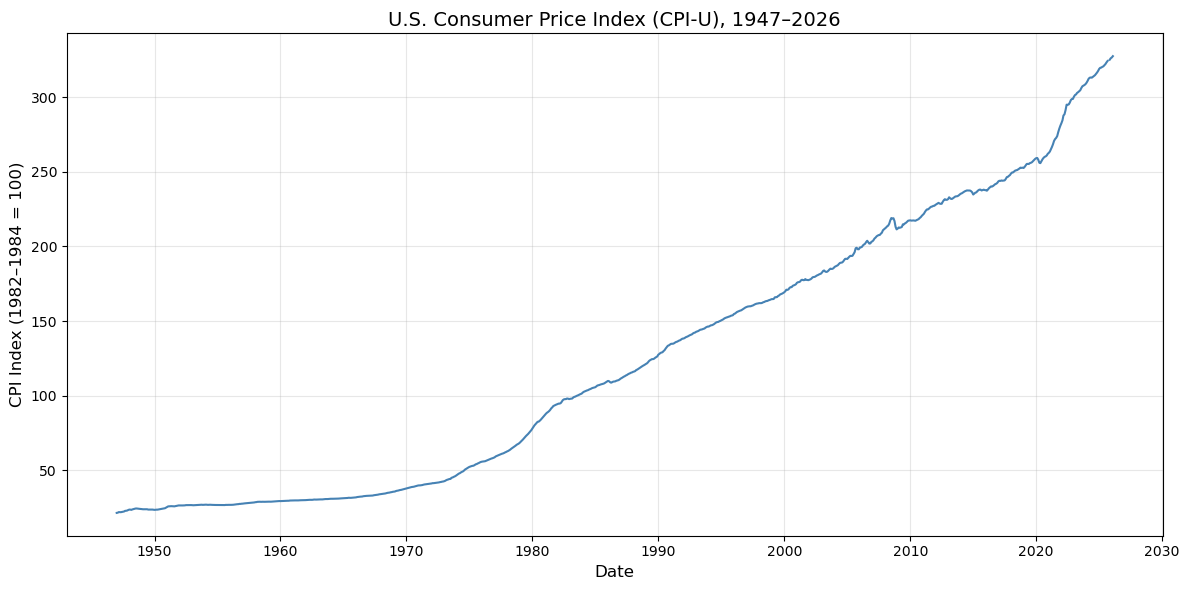

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data, parse date, set as index
file_path = r'D:\github\AAE625_2026\CPIAUCSL_26.xlsx'
cpi = pd.read_excel(file_path, sheet_name='Monthly', parse_dates=['observation_date'])
cpi.set_index('observation_date', inplace=True)

# Display first and last 5 rows
print("First 5 rows:")
print(cpi.head())
print("\nLast 5 rows:")
print(cpi.tail())

# Report summary
print(f"\nNumber of observations: {len(cpi)}")
print(f"Date range: {cpi.index.min().strftime('%Y-%m')} to {cpi.index.max().strftime('%Y-%m')}")
print(f"Missing values:\n{cpi.isnull().sum()}")

# Plot CPI level over full time series
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cpi.index, cpi['CPIAUCSL'], color='steelblue', linewidth=1.5)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('CPI Index (1982–1984 = 100)', fontsize=12)
ax.set_title('U.S. Consumer Price Index (CPI-U), 1947–2026', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Q4_CPI_timeseries.png', dpi=150)
plt.show()

### Question 5: Year-over-Year Inflation Rate

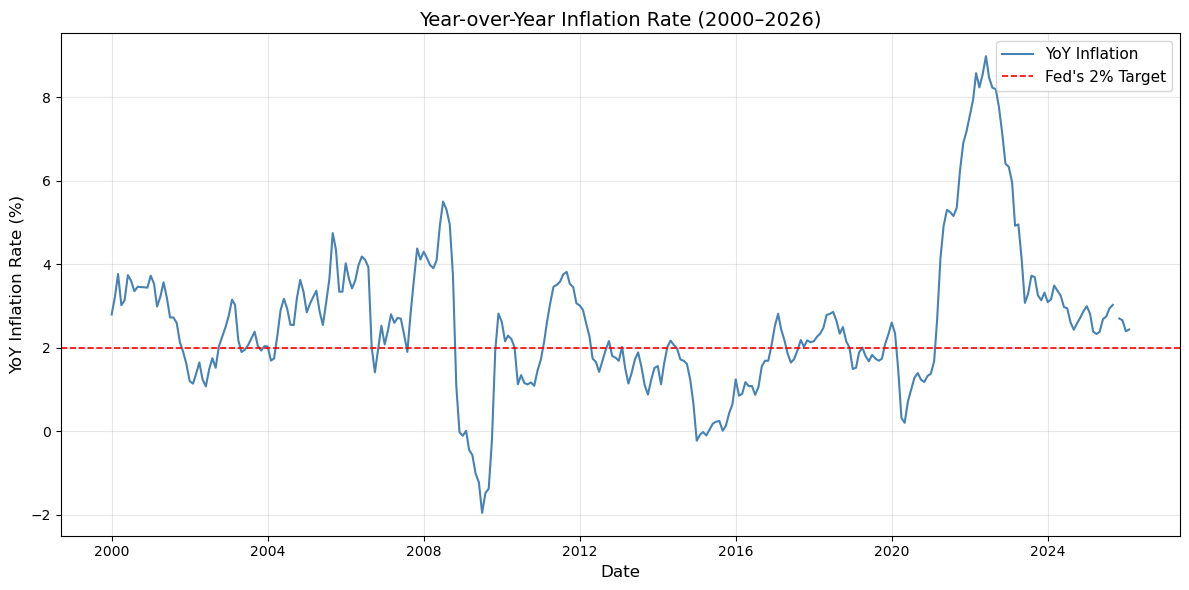


YoY Inflation Rate for January 2026: 2.39%
Highest YoY Inflation since 2000: 8.98% in June 2022


In [19]:
# Compute YoY Inflation (fix FutureWarning)
cpi['YoY_Inflation'] = (cpi['CPIAUCSL'] - cpi['CPIAUCSL'].shift(12)) / cpi['CPIAUCSL'].shift(12) * 100

# Plot YoY inflation from 2000 to 2026
cpi_2000 = cpi.loc['2000':]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cpi_2000.index, cpi_2000['YoY_Inflation'], color='steelblue', linewidth=1.5, label='YoY Inflation')
ax.axhline(y=2, color='red', linestyle='--', linewidth=1.2, label="Fed's 2% Target")
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('YoY Inflation Rate (%)', fontsize=12)
ax.set_title('Year-over-Year Inflation Rate (2000–2026)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Q5_YoY_inflation.png', dpi=150)
plt.show()

# (c) YoY inflation for January 2026 — use .iloc[0] to extract scalar
jan_2026 = cpi.loc['2026-01', 'YoY_Inflation']
if isinstance(jan_2026, pd.Series):
    jan_2026 = jan_2026.iloc[0]
print(f"\nYoY Inflation Rate for January 2026: {jan_2026:.2f}%")

# (d) Highest YoY inflation since 2000
max_row = cpi_2000['YoY_Inflation'].idxmax()
max_val = cpi_2000.loc[max_row, 'YoY_Inflation']
print(f"Highest YoY Inflation since 2000: {max_val:.2f}% in {max_row.strftime('%B %Y')}")

> **YoY inflation rate for January 2026:** **2.39%**

> **Highest YoY inflation since 2000:** **8.98% in June 2022**

This peak was the result of multiple factors working together. Firstly, during the COVID-19 pandemic, large-scale fiscal stimulus measures were implemented, such as the Federal Reserve maintaining near-zero interest rates until early 2022, which drove demand-pull inflation. At the same time, global supply chain disruptions, semiconductor shortages, and the conflict between Russia and Ukraine led to significant increases in energy and food prices, thereby triggering severe cost-push inflation.

### Question 6: Month-over-Month Inflation

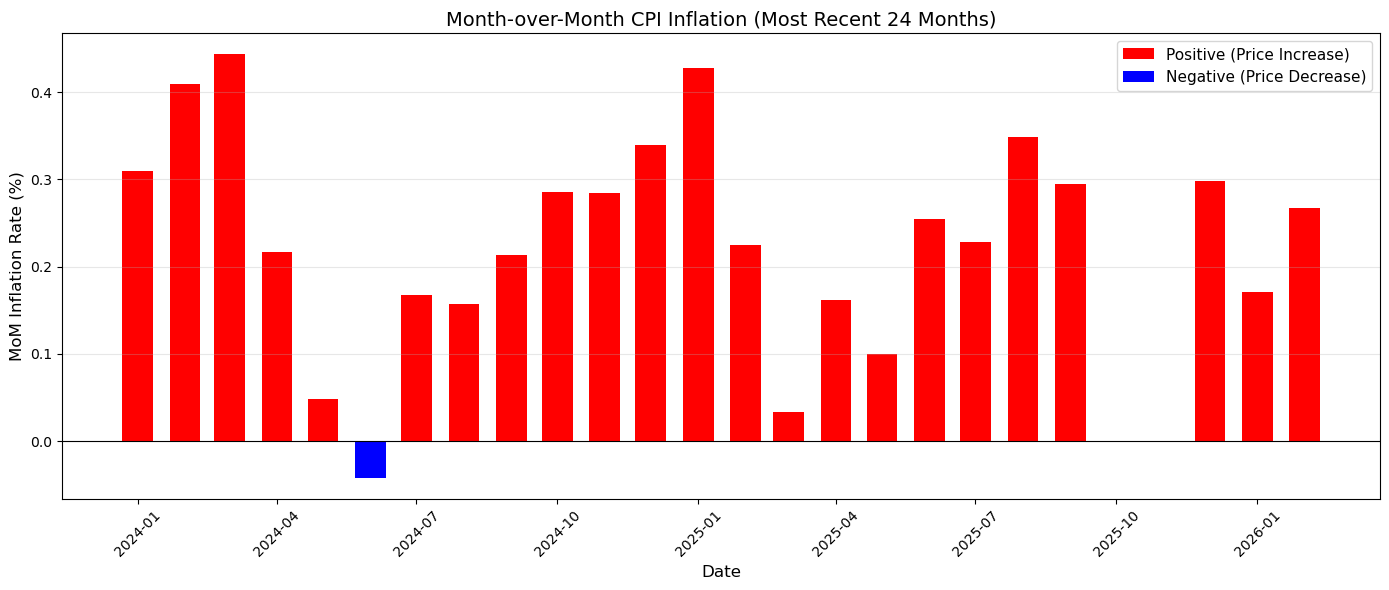

MoM Inflation — Most Recent 24 Months:
observation_date
2024-01-01    0.309969
2024-02-01    0.409754
2024-03-01    0.443134
2024-04-01    0.217068
2024-05-01    0.048559
2024-06-01   -0.041830
2024-07-01    0.167708
2024-08-01    0.157222
2024-09-01    0.213334
2024-10-01    0.285640
2024-11-01    0.284193
2024-12-01    0.339938
2025-01-01    0.427262
2025-02-01    0.225106
2025-03-01    0.033158
2025-04-01    0.161671
2025-05-01    0.099281
2025-06-01    0.254195
2025-07-01    0.228351
2025-08-01    0.348264
2025-09-01    0.295090
2025-12-01    0.297788
2026-01-01    0.170843
2026-02-01    0.267003


In [20]:
# Calculate MoM inflation rate
cpi['MoM_Inflation'] = (cpi['CPIAUCSL'] - cpi['CPIAUCSL'].shift(1)) / cpi['CPIAUCSL'].shift(1) * 100

# Bar chart for the most recent 24 months, red=positive, blue=negative
recent_24 = cpi['MoM_Inflation'].dropna().tail(24)
colors = ['red' if v >= 0 else 'blue' for v in recent_24.values]

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(recent_24.index, recent_24.values, color=colors, width=20)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('MoM Inflation Rate (%)', fontsize=12)
ax.set_title('Month-over-Month CPI Inflation (Most Recent 24 Months)', fontsize=14)
ax.tick_params(axis='x', rotation=45)

# Custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', label='Positive (Price Increase)'),
                   Patch(facecolor='blue', label='Negative (Price Decrease)')]
ax.legend(handles=legend_elements, fontsize=11)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('Q6_MoM_inflation.png', dpi=150)
plt.show()

# Print recent 24 months for reference
print("MoM Inflation — Most Recent 24 Months:")
print(recent_24.to_string())

**Why economists usually prefer YoY over MoM？**
MoM figures bounce around a lot because of seasonal factors, for example,gas prices going up in summer or clothes getting cheaper after the holidays. That makes it hard to see what's really happening. YoY numbers fix that by comparing the same month from one year to the next.
Also, one weird month can send monthly numbers way up or down, and then they might flip right back. That kind of noise could trick someone into making bad choices. Yearly numbers smooth that out and give a steadier picture.

### Question 7. Comparing Inflation Across Periods

Average Annual Inflation Rate by Period:
  2000–2007: 2.78%
  2008–2009: 1.76%
  2010–2019: 1.77%
  2020–2023: 4.52%
  2024–2026: 2.80%


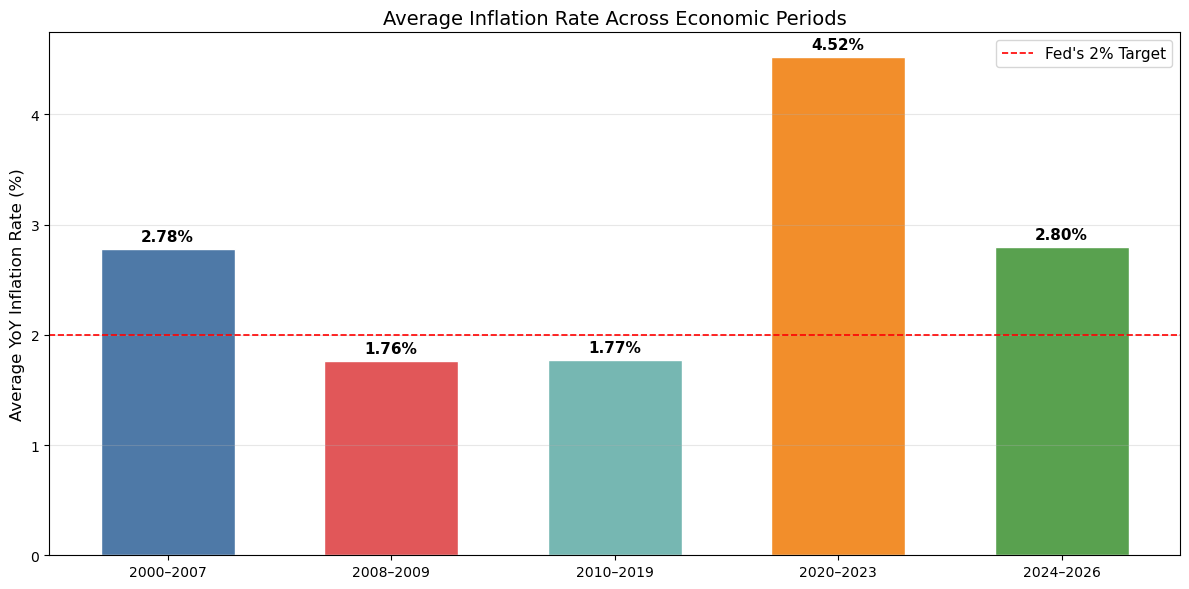

In [23]:
# ============ Question 7: Comparing Inflation Across Periods ============

# Compute average annual inflation rate for each period
periods = {
    '2000–2007': ('2000', '2007'),
    '2008–2009': ('2008', '2009'),
    '2010–2019': ('2010', '2019'),
    '2020–2023': ('2020', '2023'),
    '2024–2026': ('2024', '2026'),
}

avg_inflation = {}
for label, (start, end) in periods.items():
    subset = cpi.loc[start:end, 'YoY_Inflation'].dropna()
    avg_inflation[label] = subset.mean()

print("Average Annual Inflation Rate by Period:")
for label, val in avg_inflation.items():
    print(f"  {label.replace(chr(10), ' ')}: {val:.2f}%")

# Bar chart comparing average inflation across periods
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#4e79a7', '#e15759', '#76b7b2', '#f28e2b', '#59a14f']
bars = ax.bar(avg_inflation.keys(), avg_inflation.values(), color=colors, edgecolor='white', width=0.6)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.05,
            f'{height:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.axhline(y=2, color='red', linestyle='--', linewidth=1.2, label="Fed's 2% Target")
ax.set_ylabel('Average YoY Inflation Rate (%)', fontsize=12)
ax.set_title('Average Inflation Rate Across Economic Periods', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('Q7_inflation_periods.png', dpi=150)
plt.show()

**2000–2007**
This period's average YoY inflation was **2.78%**, mainly driven by sustained economic growth, rising house prices, and increasing commodity costs. As consumer spending and credit expansion drove total demand,**demand-pull inflation** was the main factor.The Federal Reserve maintained a relatively loose monetary policy stance in the early 21st century and gradually tightened it later.

**2008–2009**
This period's average YoY inflation was **1.76%**. Due to the severe contraction of total demand caused by the financial crisis, the Federal Reserve lowered interest rates to a level close to zero, resulting in a sharp decline in the inflation rate. The collapse of the real estate market, tightened credit conditions, and rising unemployment rates greatly weakened consumers' purchasing power. This is a typical example of deflationary pressure triggered by a large-scale **negative demand shock**.

**2010–2019**
This period's average YoY inflation was **1.77%**. Despite unprecedented quantitative easing and low interest rates. Globalization, technological advances, and subdued wage growth kept cost-push pressures low. This era puzzled economists, as the traditional Phillips Curve relationship between unemployment and inflation appeared to weaken.

**2020–2023**
This period's average YoY inflation was **4.52%**. This period covers both the pandemic downturn and the big inflation spike that came later. All kinds of things pushed prices up—heavy government spending, people rushing to buy stuff once things reopened, supply chains that couldn't keep up, not enough workers, and energy price jumps. So it was a mix of **demand-pull** and **cost-push**.

**2024–2026**
This period's average YoY inflation was **2.80%** Inflation has moderated significantly as the Fed's tightening policy took effect and supply chains normalized. However, rates remain slightly above the 2% target, reflecting persistent services inflation and a resilient labor market.